# **Clustering Continue**

**Hierarchial Clustering**

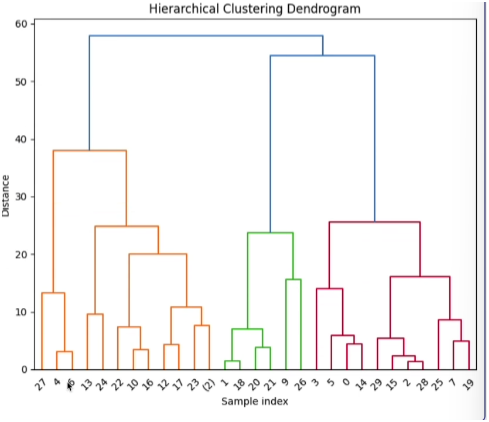

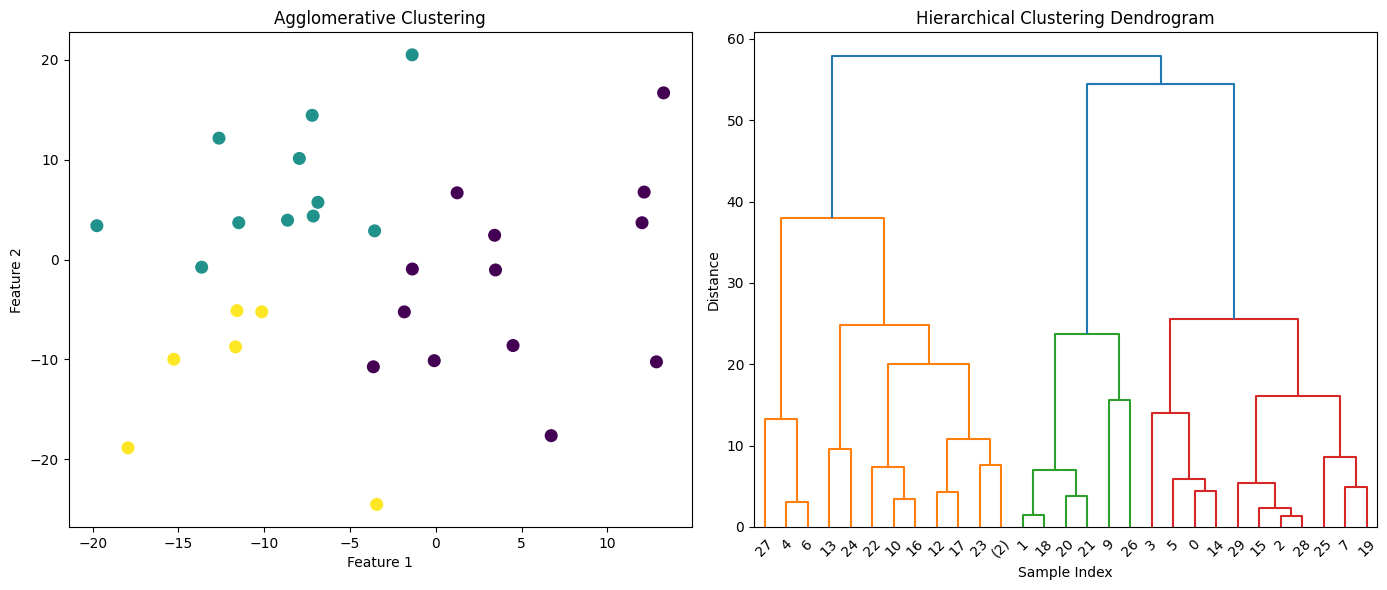

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

# Agglomerative clustering with fixed number of clusters
clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

# Agglomerative clustering for dendrogram (requires distance_threshold=0, n_clusters=None)
agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)

# Function to plot dendrogram
def plot_dendrogram(model, **kwargs):
    # Create counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0   # ✅ fixed variable name
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Build linkage matrix
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot dendrogram
    dendrogram(linkage_matrix, **kwargs)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot of clusters
ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

# Dendrogram
plt.sca(ax2)
plot_dendrogram(agg, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()


# **Divisine Clustering**

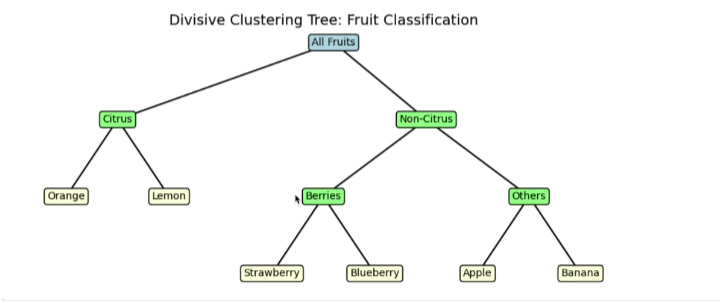

In [5]:
fruit_tree = {
    "All Fruits": {
        "Citrus": ["Orange", "Lemon"],
        "Non-Citrus": {
            "Berries": ["Strawberry", "Blueberry"],
            "Others": ["Apple", "Banana"]
        }
    }
}

In [6]:
# Compute positions for each node in the tree
def compute_positions(tree, x=0, y=0, dx=2):
    positions = {}
    width = 0

    if isinstance(tree, dict):
        for i, (key, subtree) in enumerate(tree.items()):
            sub_positions, sub_width = compute_positions(subtree, x + width * dx, y - 1, dx)
            positions.update(sub_positions)
            positions[key] = (x + width * dx + sub_width * dx / 2, y)
            width += sub_width
    elif isinstance(tree, list):
        for i, item in enumerate(tree):
            positions[item] = (x + i * dx, y)
        width = len(tree)
    else:
        positions[tree] = (x, y)
        width = 1

    return positions, width

In [7]:
# Extract edges (parent-child relationships)
def extract_edges(tree, parent=None):
    edges = []
    if isinstance(tree, dict):
        for key, subtree in tree.items():
            if parent:
                edges.append((parent, key))
            edges.extend(extract_edges(subtree, key))
    elif isinstance(tree, list):
        for item in tree:
            if parent:
                edges.append((parent, item))
    return edges

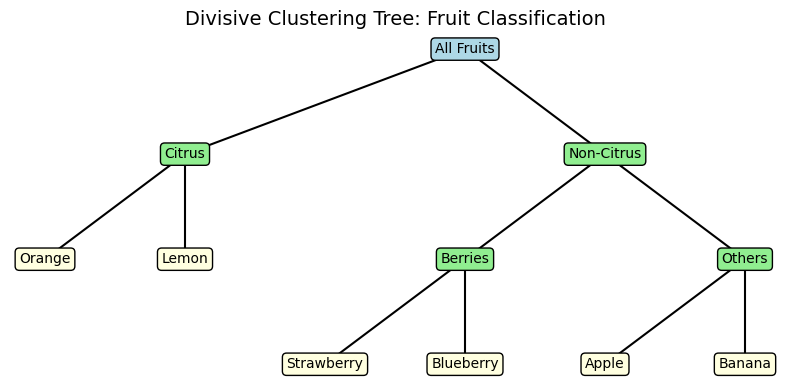

In [8]:
# Plot the tree
def plot_tree(tree):
    positions, _ = compute_positions(tree)
    edges = extract_edges(tree)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')

    # Draw edges
    for parent, child in edges:
        if parent in positions and child in positions:
            x1, y1 = positions[parent]
            x2, y2 = positions[child]
            ax.plot([x1, x2], [y1, y2], 'k-')

    # Draw nodes with colors
    for node, (x, y) in positions.items():
        if node == "All Fruits":
            color = "lightblue"
        elif node in ["Citrus", "Non-Citrus", "Berries", "Others"]:
            color = "lightgreen"
        else:
            color = "lightyellow"
        ax.text(x, y, node, ha='center', va='center',
                bbox=dict(boxstyle="round", facecolor=color, edgecolor="black"))

    plt.title("Divisive Clustering Tree: Fruit Classification", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_tree(fruit_tree)

# **DB-Scan**

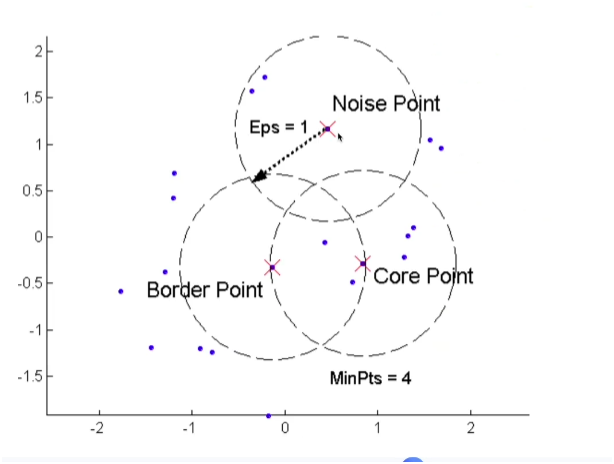

Unique labels: [-1  0  1]
Points per cluster: Counter({np.int64(0): 149, np.int64(1): 149, np.int64(-1): 2})


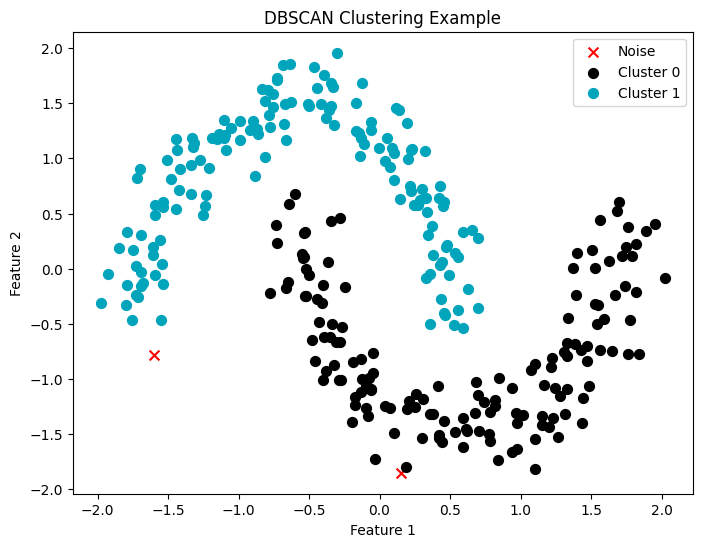

In [9]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Step 2: Create sample data
# Using make_moons to get non-linear clusters (good for DBSCAN demonstration)
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Step 3: Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Create DBSCAN model
# eps = radius, min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Step 5: Fit model
dbscan.fit(X_scaled)

# Step 6: Get cluster labels
labels = dbscan.labels_
# -1 label is noise
print("Unique labels:", np.unique(labels))

# Step 7: Count points in each cluster
print("Points per cluster:", Counter(labels))

# Step 8: Visualize clusters
plt.figure(figsize=(8,6))

for label in np.unique(labels):
    if label == -1:
        # Noise points in red
        color = 'red'
        marker = 'x'
        size = 50
        label_name = 'Noise'
    else:
        # Cluster points
        color = plt.cm.nipy_spectral(label / len(np.unique(labels)))
        marker = 'o'
        size = 50
        label_name = f'Cluster {label}'

    plt.scatter(X_scaled[labels == label, 0],
                X_scaled[labels == label, 1],
                c=[color], marker=marker, s=size, label=label_name)

plt.title("DBSCAN Clustering Example")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


In [10]:
# Step 1: Import libraries
from sklearn.cluster import DBSCAN
import numpy as np

# Step 2: Create dataset
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]
])

# Step 3: Create DBSCAN model
# eps = maximum distance between two samples for them to be considered neighbors
# min_samples = minimum number of points to form a dense region (cluster)
clustering = DBSCAN(eps=3, min_samples=2).fit(X)

# Step 4: Get cluster labels
labels = clustering.labels_
print("Cluster labels:", labels)

# Step 5: Inspect the DBSCAN object
print(clustering)


Cluster labels: [ 0  0  0  1  1 -1]
DBSCAN(eps=3, min_samples=2)


# **KNN introduction**

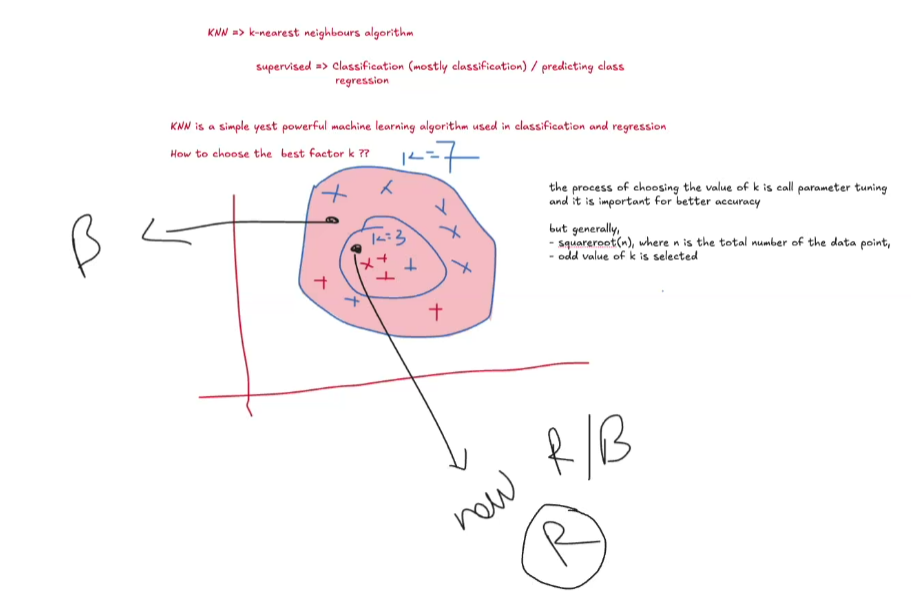

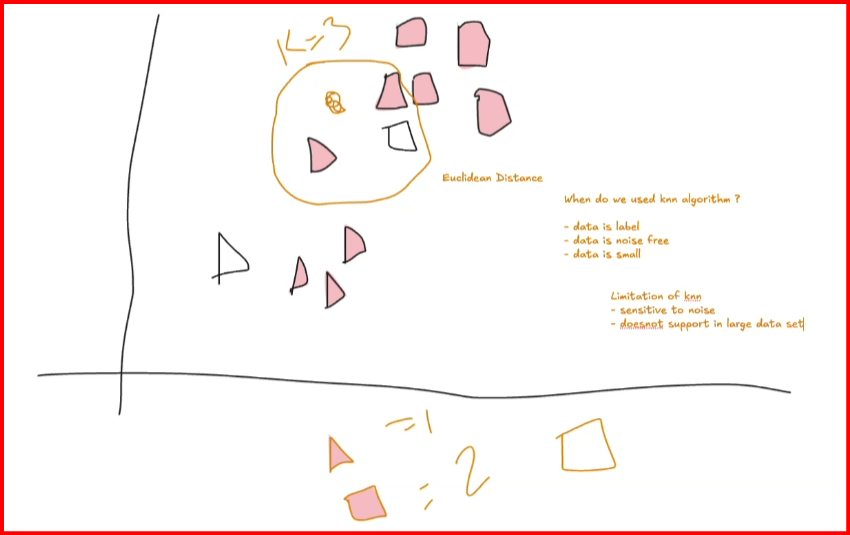